<a href="https://colab.research.google.com/github/adeynt/Adeyunita-Rachmadhani_H1D023057_PaketD/blob/main/tugas3PCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Tugas 3 - Pengolahan Citra Digital

Nama: Adeyunita Rachmadhani

NIM: H1D023057

In [78]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [79]:
def my_convolution(img, kernel, padding_type='zero'):
    if len(img.shape) != 2:
        raise ValueError("Input harus grayscale.")

    if padding_type.lower() != 'zero':
        raise ValueError("Hanya untuk zero padding.")

    tinggi, lebar = img.shape
    k_tinggi, k_lebar = kernel.shape

    if k_tinggi % 2 == 0 or k_lebar % 2 == 0:
        raise ValueError("Ukuran kernel harus ganjil.")

    pad_y = k_tinggi // 2
    pad_x = k_lebar // 2
    kernel_balik = np.flipud(np.fliplr(kernel))

    img_pad = np.pad(
        img,
        ((pad_y, pad_y), (pad_x, pad_x)),
        mode='constant',
        constant_values=0
    )

    hasil = np.zeros((tinggi, lebar), dtype=np.float64)

    for baris in range(tinggi):
        for kolom in range(lebar):
            potong = img_pad[baris:baris + k_tinggi, kolom:kolom + k_lebar]
            hasil[baris, kolom] = np.sum(potong * kernel_balik)
    return hasil


def tampilkan_perbandingan(img_asli, img_hasil, judul):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_asli, cmap='gray')
    plt.title('Citra Asli')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(img_hasil, cmap='gray')
    plt.title(judul)
    plt.axis('off')
    plt.show()

def normalisasi(img):
    img = np.abs(img)
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)

def tambah_noise(img, rasio=0.05):
    noisy = img.copy()
    jumlah = int(rasio * img.shape[0] * img.shape[1])
    y = np.random.randint(0, img.shape[0], jumlah)
    x = np.random.randint(0, img.shape[1], jumlah)
    noisy[y, x] = 255
    y = np.random.randint(0, img.shape[0], jumlah)
    x = np.random.randint(0, img.shape[1], jumlah)
    noisy[y, x] = 0
    return noisy

In [80]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

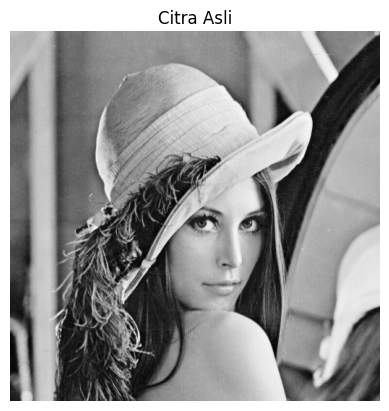

In [81]:
img = cv2.imread('/content/drive/MyDrive/PCD/lena 1.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(img, cmap='gray')
plt.title("Citra Asli")
plt.axis('off')

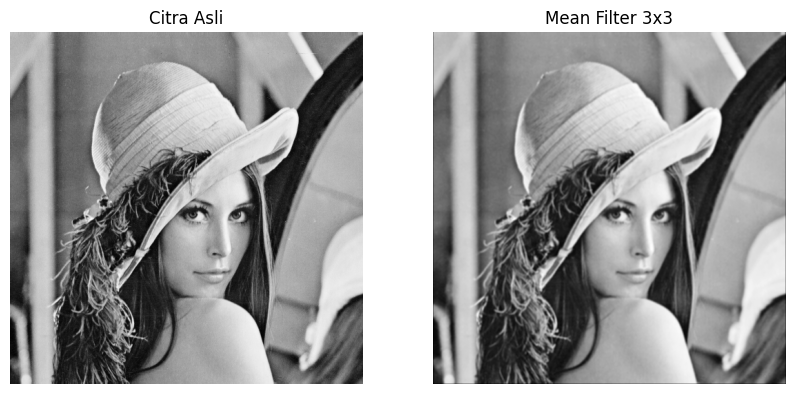

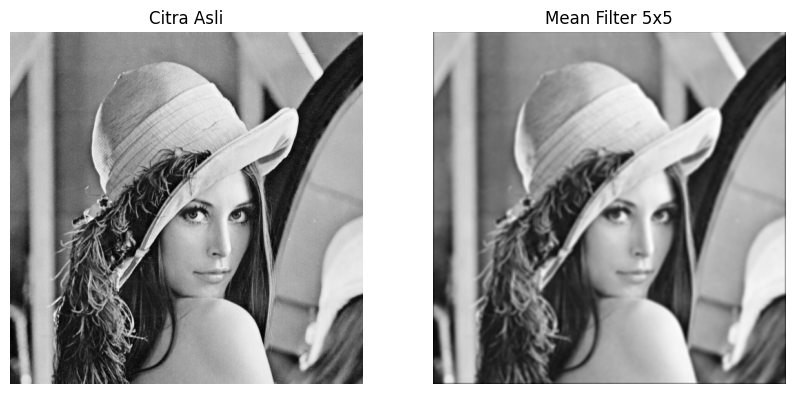

In [82]:
kernel_mean_3 = np.ones((3, 3)) / 9
kernel_mean_5 = np.ones((5, 5)) / 25
hasil_3 = normalisasi(my_convolution(img, kernel_mean_3))
hasil_5 = normalisasi(my_convolution(img, kernel_mean_5))
tampilkan_perbandingan(img, hasil_3, "Mean Filter 3x3")
tampilkan_perbandingan(img, hasil_5, "Mean Filter 5x5")

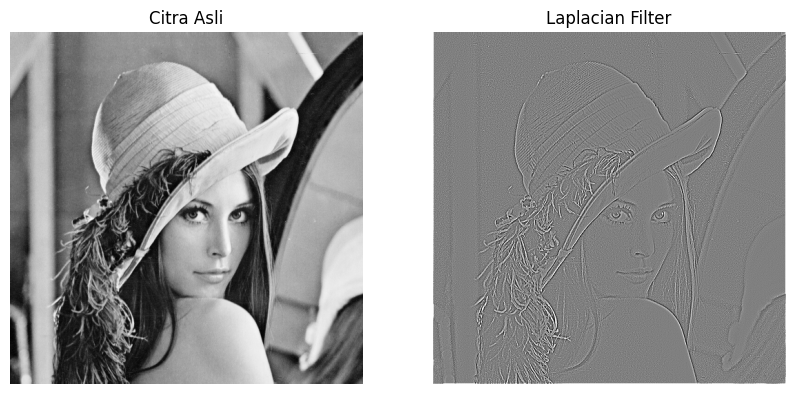

In [83]:
kernel_lap = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
])

hasil_lap = my_convolution(img, kernel_lap)
hasil_lap = np.clip(hasil_lap + 128, 0, 255).astype(np.uint8)
tampilkan_perbandingan(img, hasil_lap, "Laplacian Filter")

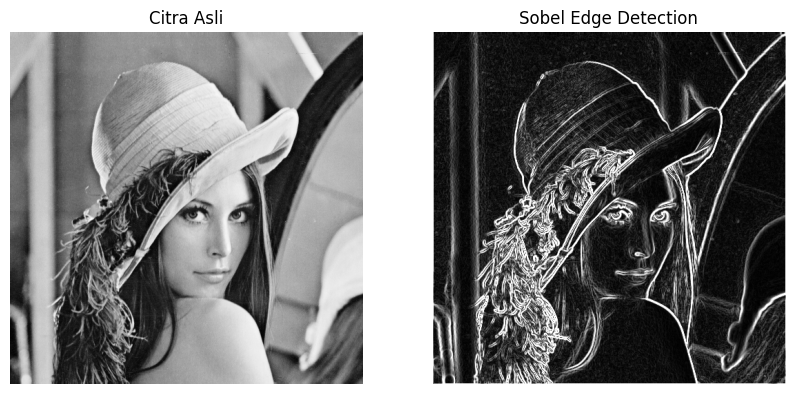

In [84]:
sobel_x = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

sobel_y = np.array([
    [-1,-2,-1],
    [0,0,0],
    [1,2,1]
])

gx = my_convolution(img, sobel_x)
gy = my_convolution(img, sobel_y)
sobel = np.sqrt(gx**2 + gy**2)
sobel = np.clip(sobel, 0, 255).astype(np.uint8)
tampilkan_perbandingan(img, sobel, "Sobel Edge Detection")

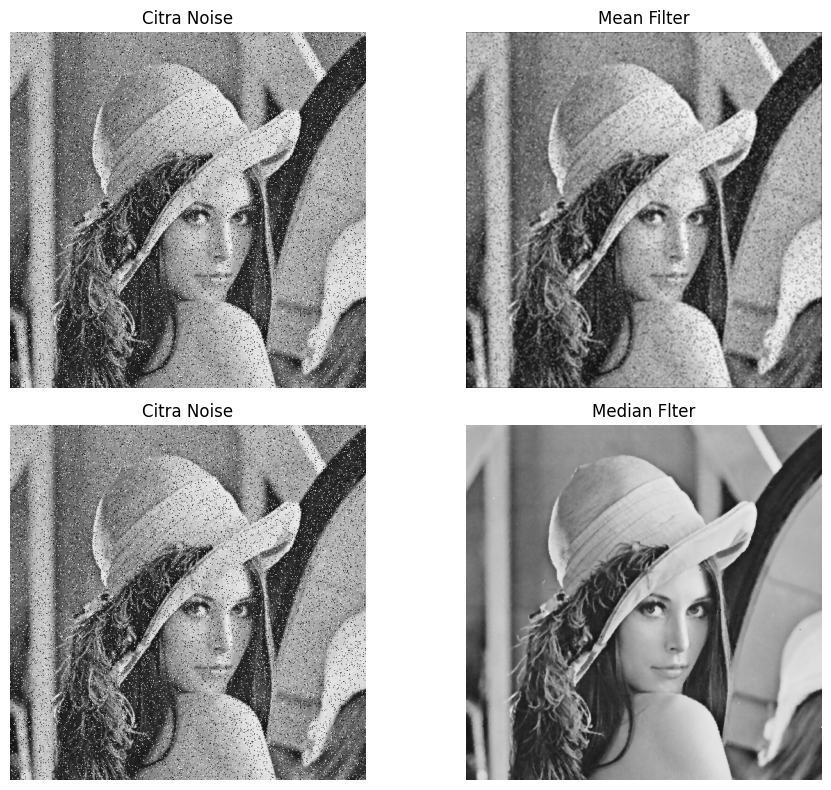

In [86]:
img_noise = tambah_noise(img)
mean_noise = normalisasi(my_convolution(img_noise, kernel_mean_3))
median_noise = cv2.medianBlur(img_noise, 3)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_noise, cmap='gray')
plt.title("Citra Noise")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(mean_noise, cmap='gray')
plt.title("Mean Filter")
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_noise, cmap='gray')
plt.title("Citra Noise")
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(median_noise, cmap='gray')
plt.title("Median Flter")
plt.axis('off')

plt.tight_layout()
plt.show()